In [2]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [6]:
pgroup = 'p22588'
runlist = [102]

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 102


100%|██████████| 47/47 [00:20<00:00,  2.29it/s]


In [264]:
#plot_merged_data(data, meta, Signal='diode2', Izero='Izero110', TT='126', withTT=True, bins=100, figsize=(10, 3))

In [7]:
ui, out  = Rebin_widget(data=data)
ui

Data saved in /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0102/


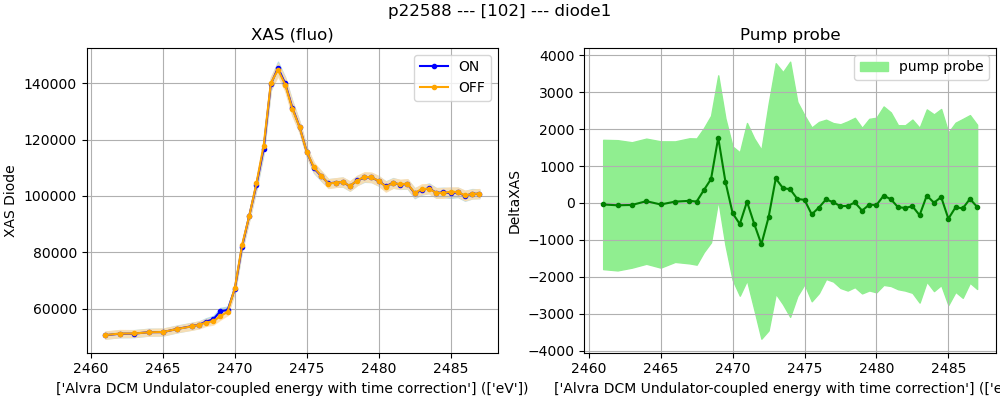

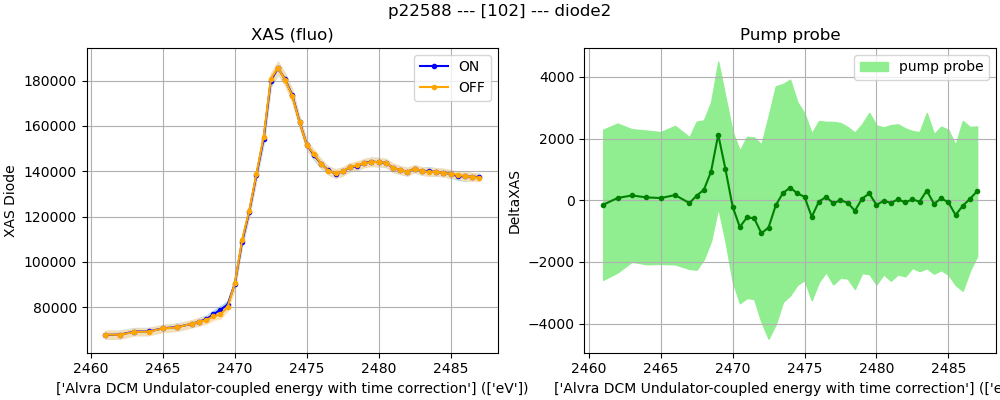

In [8]:
data_plot1 = {"results": out['results1'], "params": out['params'], "which": "signal1"}
data_plot2 = {"results": out['results2'], "params": out['params'], "which": "signal2"}

SaveDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2)

fig, axes = plotter.energy_scans(data_plot1, meta)
fig, axes = plotter.energy_scans(data_plot2, meta)

Data saved in /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0102/


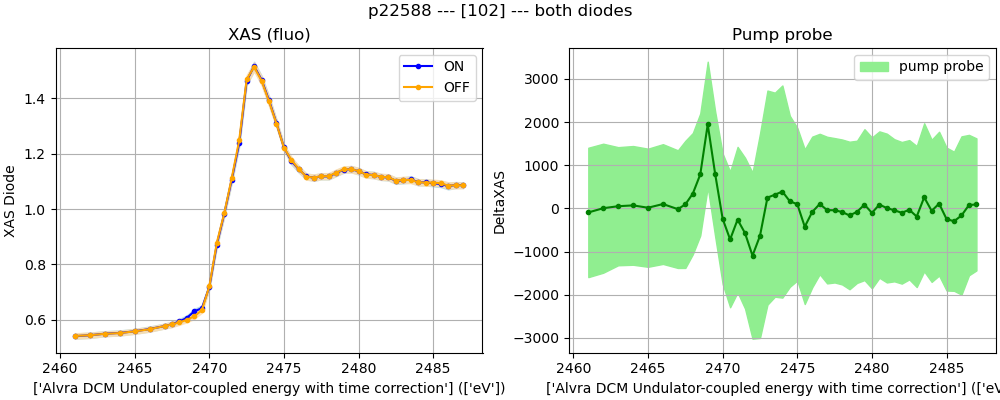

In [9]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=data_plot_both)
fig, axes = plotter.energy_scans(data_plot_both, meta)


# Overlay data with UI

In [73]:
pgroup = 'p22588'
which_plot = 'both' #ploboth #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
selector = RunSelectorUI(LoadDir)

Loaded __both diodes__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0101/data.npz
Loaded __both diodes__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0102/data.npz
Loaded __both diodes__ from: /sf/alvra/data/p22588/work/Reduced_data2/_multiruns/run0101_0102/data.npz


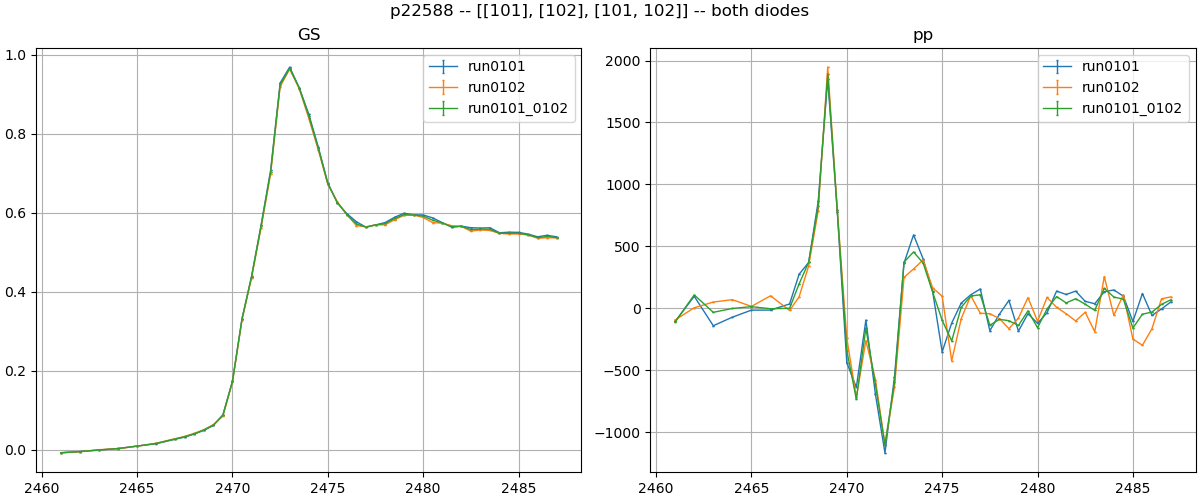

In [60]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS - np.mean(GS[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'upper right')
ax3.set_title('pp')
ax3.grid()
plt.show()

# Overlay data "manually"

In [51]:
pgroup = 'p22588'
runlist2load = [[100], [101], [102], [103]]

which_plot = 'plot1' #plot_both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data2/'.format(pgroup)
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
#selector = RunSelectorUI(LoadDir)

Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0100/data.npz
Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0101/data.npz
Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0102/data.npz
Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data2/_singlerun/run0103/data.npz


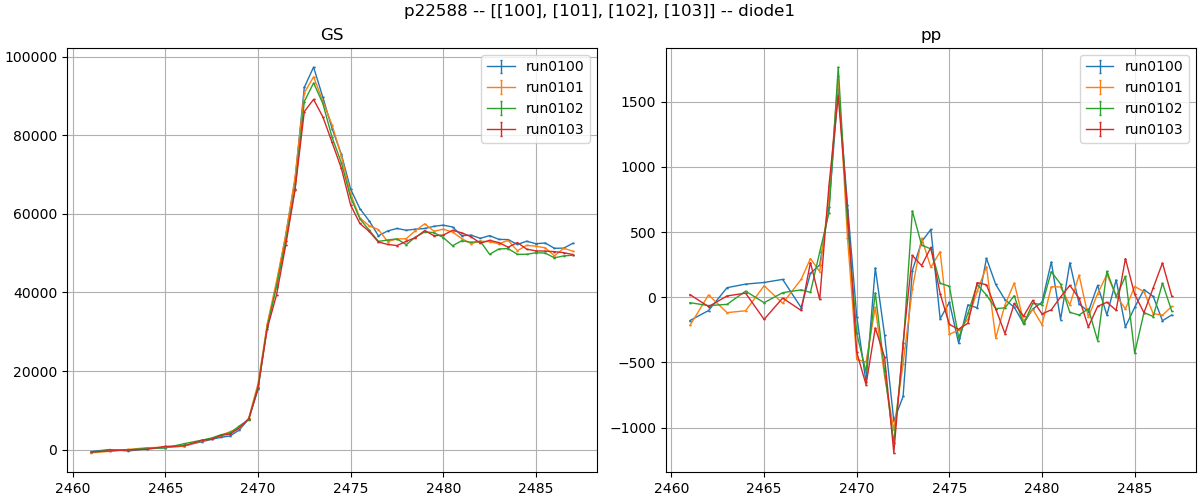

In [52]:
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS - np.mean(GS[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'upper right')
ax3.set_title('pp')
ax3.grid()
plt.show()
